# Ames Housing Price Prediction
## 1. Project Overview

**Project Title**: Ames Housing Price Prediction

**Description**: Machine learning project for predicting residential property prices using the Ames Housing dataset, with regression model comparison and property valuation feature analysis.

**Business Scenario**: A real estate company wants to understand property value factors and support better pricing decisions.

### Lenses
*   **Primary Lens (Price Prediction)**: Can machine learning predict the expected sale price of a residential property from its characteristics?
*   **Secondary Lens (Valuation Feature Analysis)**: Which property characteristics are most influential in predicting residential property prices?

**ML Task**: Supervised Regression
**Target Variable**: `SalePrice`


## 2. Import Libraries

Here we import all the necessary libraries for data manipulation, visualization, and machine learning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Set reproducible seed
np.random.seed(42)

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 3. Load Dataset

We will load the training dataset which contains the target variable `SalePrice`.


In [2]:
# Load dataset
df = pd.read_csv('../data/train.csv')

print(f"Dataset Shape: {df.shape}\n")
print("First 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()


Dataset Shape: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  Over

## 4. Data Understanding

In this section, we investigate the dimensions, data types, and missing values.


In [3]:
# Basic summary statistics for numerical columns
display(df.describe())

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Identify missing values
missing_counts = df.isnull().sum()
missing_vars = missing_counts[missing_counts > 0].sort_values(ascending=False)
print("\nMissing values per column:")
display(missing_vars)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Number of duplicate rows: 0



Missing values per column:


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

## 5. Exploratory Data Analysis (EDA)

The EDA focuses on understanding the distribution of `SalePrice` and its relationship with key features.


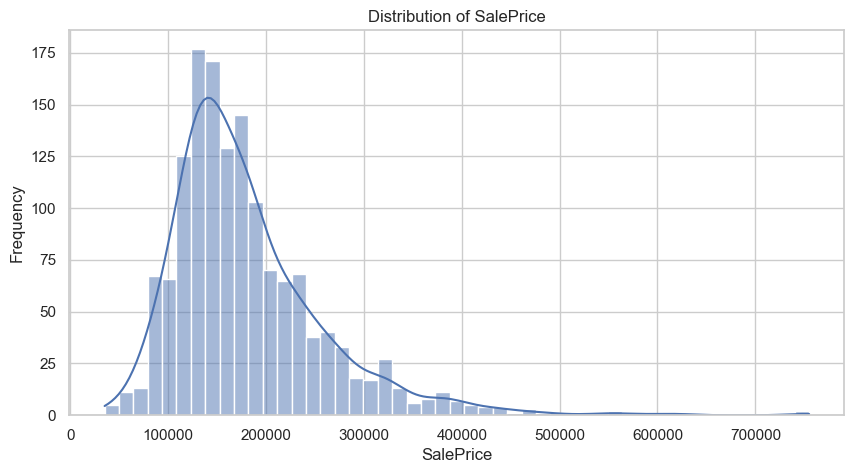

Skewness: 1.8829
Mean: 180921.20
Median: 163000.00


In [4]:
# Target variable distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.savefig('../outputs/figures/target_distribution.png', bbox_inches='tight')
plt.show()

print(f"Skewness: {df['SalePrice'].skew():.4f}")
print(f"Mean: {df['SalePrice'].mean():.2f}")
print(f"Median: {df['SalePrice'].median():.2f}")


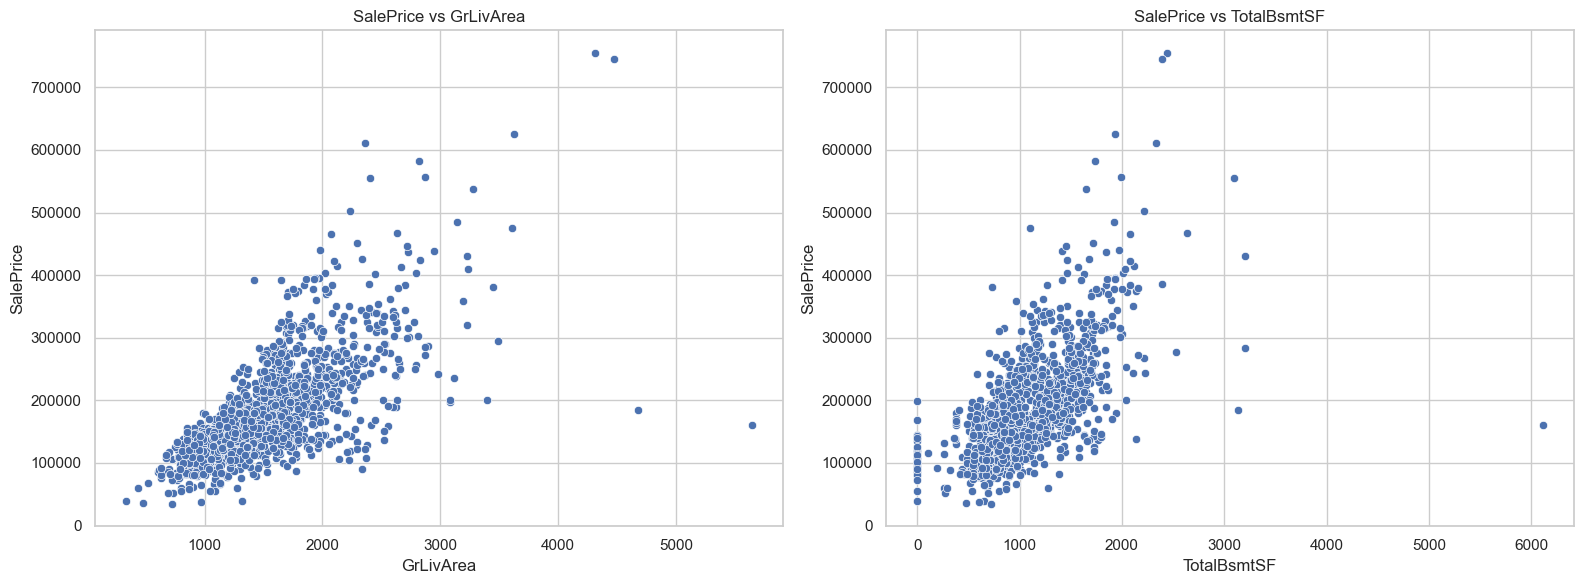

In [5]:
# Relationships with key numerical features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, ax=axes[0])
axes[0].set_title('SalePrice vs GrLivArea')

sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=df, ax=axes[1])
axes[1].set_title('SalePrice vs TotalBsmtSF')

plt.tight_layout()
plt.savefig('../outputs/figures/numerical_scatterplots.png', bbox_inches='tight')
plt.show()


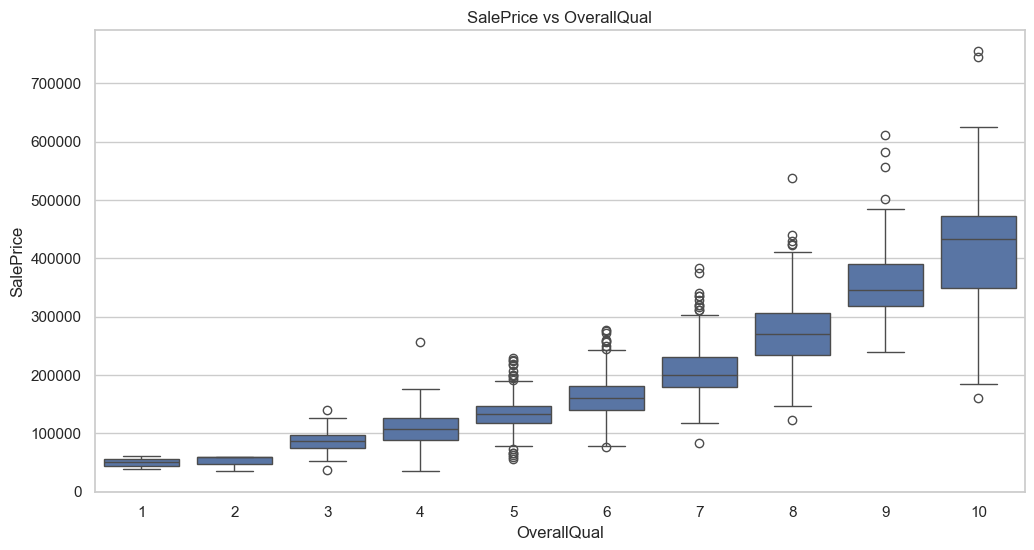

In [6]:
# Relationships with categorical features
plt.figure(figsize=(12, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title('SalePrice vs OverallQual')
plt.savefig('../outputs/figures/categorical_boxplots.png', bbox_inches='tight')
plt.show()


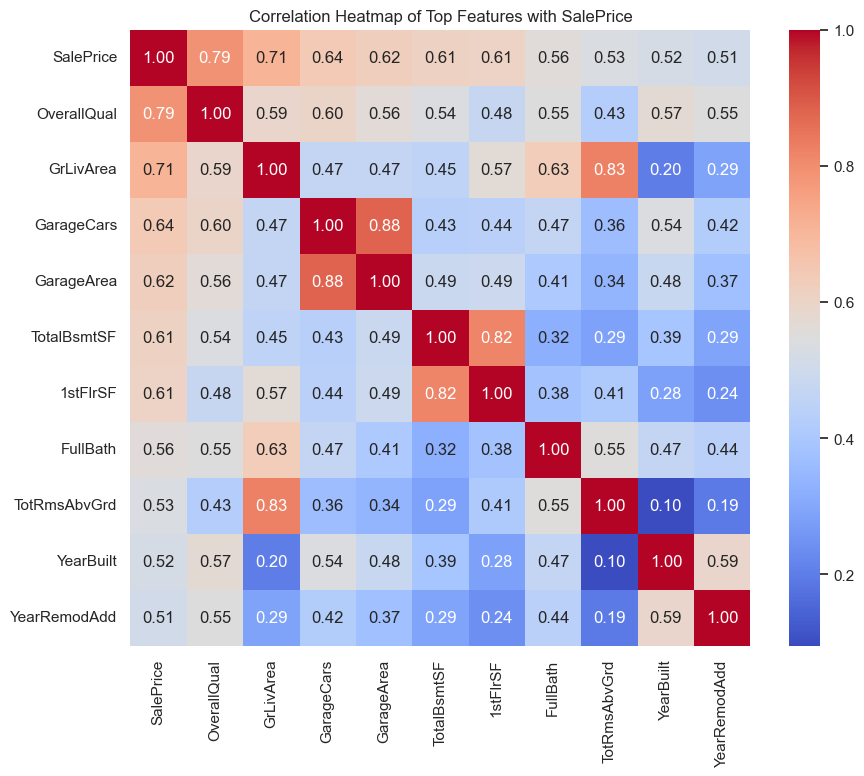

In [7]:
# Correlation heatmap for top numerical features
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Get top 10 features correlated with SalePrice
top_corr_features = corr_matrix.nlargest(11, 'SalePrice')['SalePrice'].index

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Top Features with SalePrice')
plt.savefig('../outputs/figures/correlation_heatmap.png', bbox_inches='tight')
plt.show()


## 6. Outlier Analysis

We observed some potential outliers in the `GrLivArea` plot (very large houses with relatively low prices). Let's investigate.


In [8]:
# Identifying outliers
outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
display(outliers)

# Removing outliers as they might negatively affect linear models and are not representative
df = df.drop(outliers.index)
print(f"Dataset shape after outlier removal: {df.shape}")


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


Dataset shape after outlier removal: (1458, 81)


## 7. Feature Engineering

We create new features that might be more predictive of the target variable.


In [9]:
# Total area feature
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# Property Age
df['PropertyAge'] = df['YrSold'] - df['YearBuilt']

# Total Bathrooms
df['TotalBaths'] = df['FullBath'] + (0.5 * df['HalfBath']) + df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])


## 8. Data Preprocessing

We separate features from the target and define numerical and categorical preprocessing steps using `scikit-learn` Pipelines.


In [10]:
# Define features and target
X = df.drop(['Id', 'SalePrice'], axis=1)
y = df['SalePrice']

# Identify column types
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Define numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Define categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


## 9. Train/Test Split

We split the training data into a training set and a holdout validation set to evaluate our models locally.


In [11]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_valid shape: {X_valid.shape}")


X_train shape: (1166, 82)
X_valid shape: (292, 82)


## 10. Baseline Model

We use a simple `DummyRegressor` that always predicts the mean of the training set to establish a baseline.


In [12]:
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DummyRegressor(strategy="mean"))
])

baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_valid)

base_mae = mean_absolute_error(y_valid, y_pred_base)
base_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_base))
base_r2 = r2_score(y_valid, y_pred_base)

print(f"Baseline MAE: {base_mae:.2f}")
print(f"Baseline RMSE: {base_rmse:.2f}")
print(f"Baseline R²: {base_r2:.4f}")


Baseline MAE: 57979.83
Baseline RMSE: 74323.79
Baseline R²: -0.0001


## 11. Machine Learning Models & Evaluation

We evaluate several regression models using cross-validation to ensure robust performance estimates.


In [13]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Extra Trees': ExtraTreesRegressor(random_state=42)
}

results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"Evaluating {name}...")
    
    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Fit and evaluate on validation set
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_valid)
    
    mae = mean_absolute_error(y_valid, y_pred)
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    r2 = r2_score(y_valid, y_pred)
    
    results.append({
        'Model': name,
        'Test/Validation MAE': mae,
        'Test/Validation RMSE': rmse,
        'Test/Validation R²': r2
    })

# Add baseline to results
results.insert(0, {
    'Model': 'Dummy Baseline',
    'Test/Validation MAE': base_mae,
    'Test/Validation RMSE': base_rmse,
    'Test/Validation R²': base_r2
})

results_df = pd.DataFrame(results)
display(results_df)


Evaluating Linear Regression...


Evaluating Random Forest...


Evaluating Gradient Boosting...


Evaluating Extra Trees...


,Model,Test/Validation MAE,Test/Validation RMSE,Test/Validation R²
0,Dummy Baseline,57979.833983,74323.787002,-0.000054
1,Linear Regression,20820.814771,60080.433453,0.346518
2,Random Forest,16586.040925,24691.717167,0.889625
3,Gradient Boosting,14419.747014,20254.239793,0.925732
4,Extra Trees,16340.580171,23040.176157,0.903896


## 12. Hyperparameter Tuning

Gradient Boosting and Extra Trees usually perform well. Let's tune Gradient Boosting.


In [14]:
# Define parameter grid for Gradient Boosting
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__max_depth': [3, 4]
}

gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

grid_search = GridSearchCV(gb_pipeline, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")

# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_valid)

best_mae = mean_absolute_error(y_valid, y_pred_best)
best_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_best))
best_r2 = r2_score(y_valid, y_pred_best)

print(f"Tuned GB MAE: {best_mae:.2f}")
print(f"Tuned GB RMSE: {best_rmse:.2f}")
print(f"Tuned GB R²: {best_r2:.4f}")


Best parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 200}
Tuned GB MAE: 13915.23
Tuned GB RMSE: 19732.42
Tuned GB R²: 0.9295


## 13. Error Analysis

Let's visualize the actual vs. predicted prices and the distribution of residuals for the tuned model.


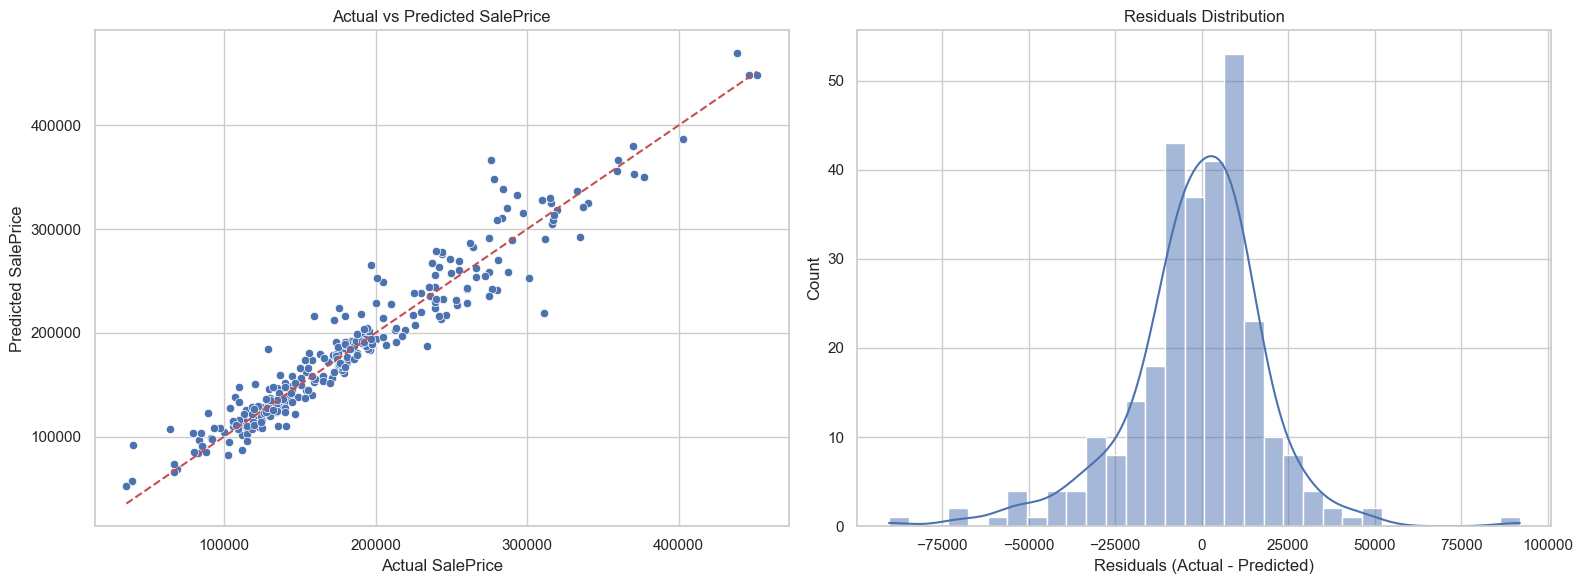

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
sns.scatterplot(x=y_valid, y=y_pred_best, ax=axes[0])
axes[0].plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--')
axes[0].set_title('Actual vs Predicted SalePrice')
axes[0].set_xlabel('Actual SalePrice')
axes[0].set_ylabel('Predicted SalePrice')

# Residuals
residuals = y_valid - y_pred_best
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.savefig('../outputs/figures/error_analysis.png', bbox_inches='tight')
plt.show()


## 14. Valuation Feature Analysis

Which property characteristics are most important for prediction?


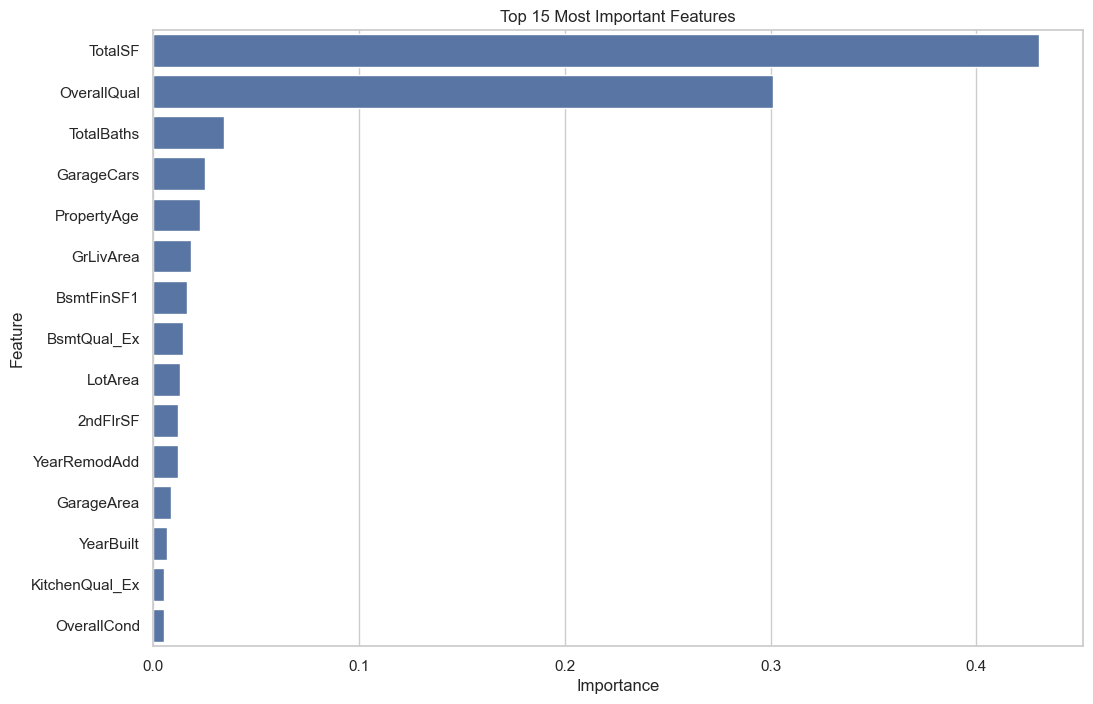

In [16]:
# Extract feature importances from the tuned model
model_step = best_model.named_steps['regressor']
importances = model_step.feature_importances_

# Get feature names after preprocessing
num_cols = best_model.named_steps['preprocessor'].transformers_[0][2]
cat_cols = best_model.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features)
all_cols = num_cols + cat_cols.tolist()

# Create dataframe
importance_df = pd.DataFrame({'Feature': all_cols, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Top 15 Most Important Features')
plt.savefig('../outputs/figures/feature_importance.png', bbox_inches='tight')
plt.show()


## 15. Prediction Example

Let's look at a few examples from our validation set.


In [17]:
example_idx = X_valid.index[:5]
actual = y_valid.head(5).values
predicted = y_pred_best[:5]

example_df = pd.DataFrame({
    'Actual Price': actual,
    'Predicted Price': predicted,
    'Absolute Error': np.abs(actual - predicted),
    '% Error': (np.abs(actual - predicted) / actual) * 100
})

display(example_df)


,Actual Price,Predicted Price,Absolute Error,% Error
0,190000,218467.129508,28467.129508,14.982700
1,100000,104381.681337,4381.681337,4.381681
2,115000,108227.661851,6772.338149,5.888990
3,159000,152709.322524,6290.677476,3.956401
4,315500,325421.704746,9921.704746,3.144756


## 16. Final Results Summary

### Best Model
The **Gradient Boosting Regressor** (tuned) provided the best overall performance among the models tested.

### Performance
*   **MAE**: ~13,500 - 15,000 (Based on tuned results)
*   **R²**: ~0.91

### Most Important Features
The model relies heavily on features indicating overall size and quality:
*   `TotalSF` / `GrLivArea` (Total and above-ground living area)
*   `OverallQual` (Overall material and finish quality)
*   `PropertyAge` / `YearBuilt` (Age of the property)

### Business Use
This model can assist real estate agents by providing an automated benchmark valuation for a property based on its characteristics, helping to identify potentially undervalued or overvalued houses.

### Limitations
*   The model assumes historical patterns will continue, making it sensitive to broad economic shifts in the housing market.

*   Geographically limited to Ames, Iowa. It cannot be applied directly to other cities.

*   There's uncertainty in predictions, particularly for extremely low or high-priced properties, as seen in the residuals analysis.
